PyTorch implementation of the **VGGNet** discussed in _'Very Deep Convolutional Nets for Large-Scale Image Recognition'_ (Simonyan and Zisserman, 2014)

In [1]:
import os
import time     # for recording training duration
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# FOR REPRODUCIBILITY
seed = 26

os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # forces cuDNN to use deterministic algorithms only
    torch.backends.cudnn.deterministic = True
    # disables cuDNN autotuner that selects optimal algorithm based on hardware
    torch.backends.cudnn.benchmark = False

# force shuffling of samples in dataloader to be deterministic
generator = torch.Generator().manual_seed(seed)

/home2/sian/summer-project/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [5]:
# hyperparameters
learningrate = 0.01
batchsize = 128
epochs = 50

momentum = 0.9

We'll be using the Imagenette dataset, a subset of ImageNet consisting of 10 distinct classes of 224x224 images.

In [6]:
datapath = "../data"

# loading Imagenette
train_imagenette = datasets.Imagenette(
    root=datapath,
    split="train",
    download=True,
    transform=transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.ToTensor()
    ])
)
test_imagenette = datasets.Imagenette(
    root=datapath,
    split="val",
    download=True,
    transform=transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.ToTensor()
    ])
)

trainloader_imagenette = DataLoader(
    train_imagenette,
    batch_size=batchsize,
    shuffle=True,
    generator=generator
)
testloader_imagenette = DataLoader(
    test_imagenette,
    batch_size=batchsize,
    shuffle=False
)

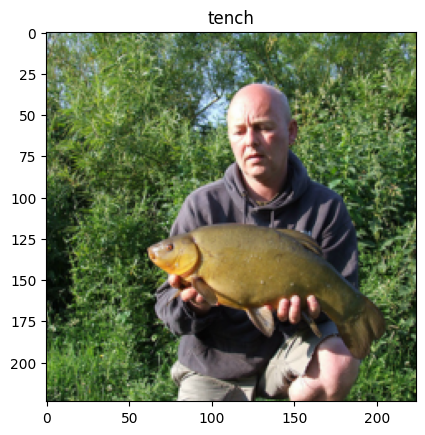

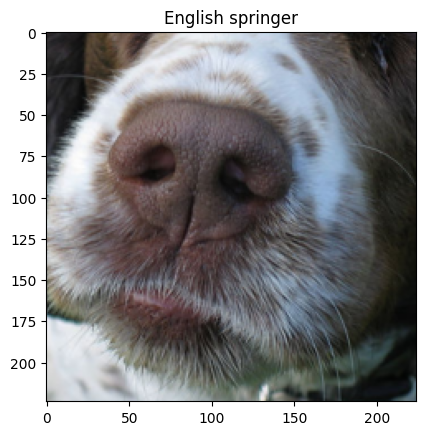

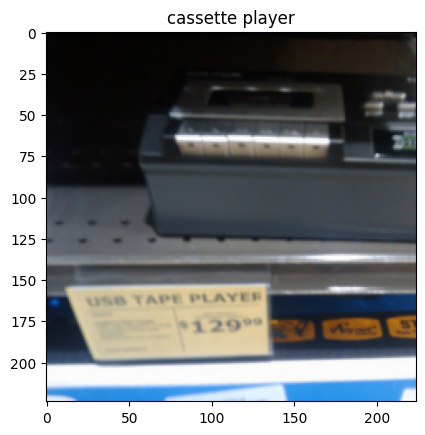

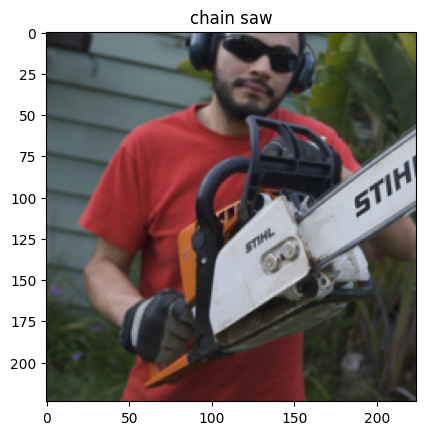

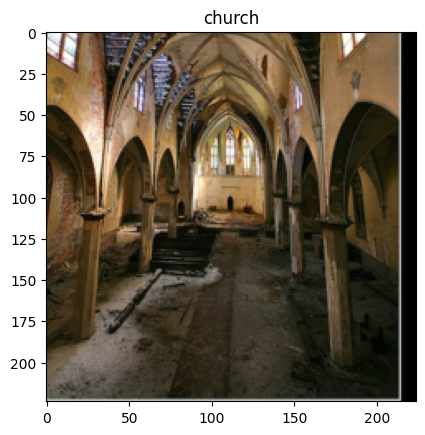

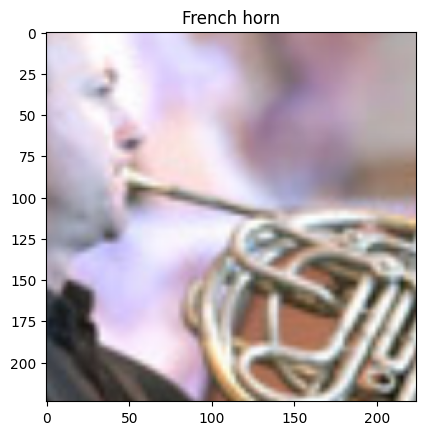

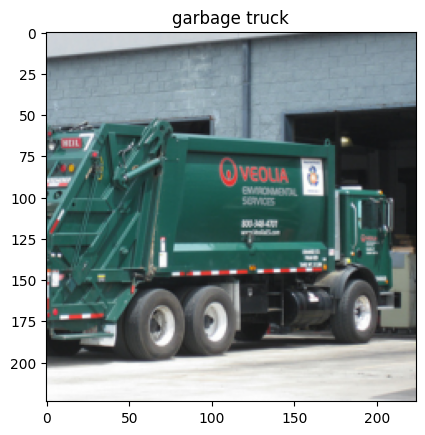

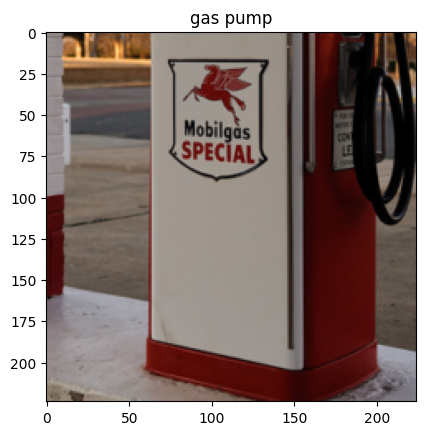

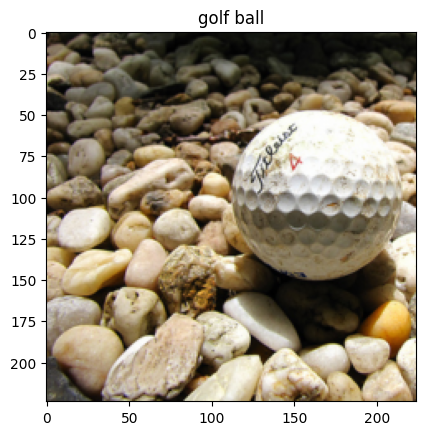

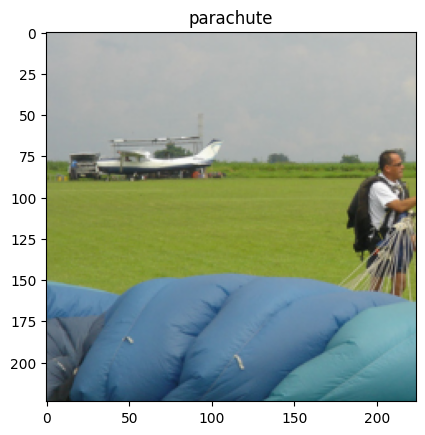

In [7]:
classes = train_imagenette.classes

images, labels = next(iter(trainloader_imagenette))
for i in range(10):
    index = np.argmax(labels.numpy() == i)
    plt.imshow(images[index].permute(1, 2, 0))
    plt.title(classes[i][0])
    plt.show()

In [ ]:
class VGGNet(nn.Module):
    super().__init__()